In [1]:
from astroquery.vizier import Vizier
import numpy as np
import pandas as pd
from astroquery.gaia import Gaia

In [2]:
viz = Vizier(columns=["*"], row_limit = -1)

catalogs = viz.get_catalogs("J/MNRAS/501/2279")

print(catalogs)

sgr = catalogs[0]

print(sgr)
print(len(sgr))
print(sgr.colnames)

TableList with 1 tables:
	'0:J/MNRAS/501/2279/catalog' with 24 column(s) and 55192 row(s) 
RAJ2000  DEJ2000   plx   ...  Lambda    Beta           SimbadName         
  deg      deg     mas   ...   deg      deg                               
-------- -------- ------ ... -------- ------- ----------------------------
  0.0357 -10.4442 -0.075 ...  -72.652  -6.886 Gaia DR2 2422822873087610624
  0.0628 -23.6540  0.050 ...  -67.073   5.093 Gaia DR2 2339739994921350912
  0.0737 -23.3191  0.045 ...  -67.225   4.794 Gaia DR2 2339854378490321280
  0.0851 -19.3309  0.022 ...  -68.925   1.186 Gaia DR2 2413932084626466432
  0.1081 -13.8471  0.098 ...  -71.266  -3.774 Gaia DR2 2420742906325713536
  0.1258 -32.0337  0.078 ...  -63.489  12.690 Gaia DR2 2314347731654668928
  0.1712 -11.8469 -0.007 ...  -72.173  -5.559 Gaia DR2 2422382548744196992
  0.2071 -15.3078 -0.013 ...  -70.733  -2.411 Gaia DR2 2416056890847075328
  0.2127   0.1796 -0.115 ...  -77.510 -16.389 Gaia DR2 2546043938621960448
     ... 

In [3]:
feh = sgr['[Fe/H]']

missing = feh.mask

sgr_with_feh = sgr[~sgr['[Fe/H]'].mask]
sgr_without_feh = sgr[sgr['[Fe/H]'].mask]

print("With metallicity:", len(sgr_with_feh))
print("Without metallicity:", len(sgr_without_feh))

With metallicity: 1772
Without metallicity: 53420


In [4]:
apogee_only = sgr_with_feh[sgr_with_feh['Ref'] == 1]

print("Stars With Apogee [Fe/H]:", len(apogee_only))

apogee_only

Stars With Apogee [Fe/H]: 893


RAJ2000,DEJ2000,plx,e_plx,pmRA,e_pmRA,pmDE,e_pmDE,Gmag,BPmag,Jmag,Hmag,Kmag,E(B-V),Dist,e_Dist,vLOS,e_vLOS,[Fe/H],e_[Fe/H],Ref,Lambda,Beta,SimbadName
deg,deg,mas,mas,mas / yr,mas / yr,mas / yr,mas / yr,mag,mag,mag,mag,mag,mag,kpc,kpc,km / s,km / s,,,,deg,deg,
float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,uint8,float64,float32,str28
3.8051,-14.5079,-0.011,0.031,-1.083,0.053,-3.034,0.035,13.97,1.93,11.64,10.81,10.62,0.02,22.18,3.56,-111.29,0.01,-0.85,0.02,1,-74.216,-1.630,Gaia DR2 2417080845410353664
4.9451,-13.7505,-0.050,0.046,-1.001,0.080,-2.778,0.042,14.92,1.60,12.92,12.13,12.02,0.03,20.88,2.05,-89.76,0.03,-0.97,0.02,1,-75.543,-1.820,Gaia DR2 2423219865504738944
5.2105,-14.3874,0.048,0.033,-1.282,0.059,-3.281,0.036,14.21,1.56,12.28,11.55,11.44,0.03,22.18,1.92,-83.25,0.04,-1.50,0.02,1,-75.490,-1.135,Gaia DR2 2416947941941974656
10.7339,-12.0148,0.004,0.042,-1.171,0.080,-3.581,0.048,14.75,1.59,12.80,12.04,11.88,0.02,19.74,4.99,-98.32,0.03,-0.67,0.02,1,-81.358,-0.788,Gaia DR2 2376974853116710912
11.2204,-12.7469,-0.009,0.036,-1.136,0.068,-3.669,0.043,13.57,2.32,10.91,10.05,9.81,0.02,22.42,2.83,-99.59,0.00,-0.84,0.02,1,-81.435,0.082,Gaia DR2 2376104349145575808
11.4152,-12.1419,-0.037,0.035,-0.669,0.073,-2.310,0.038,14.92,1.79,12.72,11.87,11.76,0.03,22.11,3.28,-105.30,0.02,-0.68,0.02,1,-81.887,-0.363,Gaia DR2 2376581502832193024
27.4345,-3.0861,0.061,0.044,-0.317,0.087,-2.491,0.063,14.77,1.52,12.85,12.15,12.05,0.03,23.85,5.34,-140.28,0.04,-1.39,0.03,1,-100.150,-0.482,Gaia DR2 2504421857231952896
27.4495,-3.1651,-0.059,0.040,-0.365,0.069,-2.204,0.063,15.01,1.70,12.91,12.13,11.99,0.03,21.16,4.84,-131.66,0.03,-0.84,0.02,1,-100.123,-0.406,Gaia DR2 2504416703271199744


In [5]:
sgr_df = sgr.to_pandas()

sgr_df.head()

,RAJ2000,DEJ2000,plx,e_plx,pmRA,e_pmRA,pmDE,e_pmDE,Gmag,BPmag,...,Dist,e_Dist,vLOS,e_vLOS,[Fe/H],e_[Fe/H],Ref,Lambda,Beta,SimbadName
0,0.0357,-10.4442,-0.075,0.099,-1.627,0.125,-3.325,0.093,16.129999,1.32,...,21.030001,1.47,NaN,NaN,NaN,NaN,0,-72.652,-6.886,Gaia DR2 2422822873087610624
1,0.0628,-23.6540,0.050,0.048,-1.148,0.072,-2.844,0.053,15.040000,1.40,...,23.629999,3.93,NaN,NaN,NaN,NaN,0,-67.073,5.093,Gaia DR2 2339739994921350912
2,0.0737,-23.3191,0.045,0.049,-2.548,0.105,-4.186,0.058,15.550000,1.25,...,22.730000,4.04,NaN,NaN,NaN,NaN,0,-67.225,4.794,Gaia DR2 2339854378490321280
3,0.0851,-19.3309,0.022,0.045,-1.882,0.084,-3.660,0.049,15.560000,1.47,...,22.820000,0.58,NaN,NaN,NaN,NaN,0,-68.925,1.186,Gaia DR2 2413932084626466432
4,0.1081,-13.8471,0.098,0.043,-1.129,0.075,-3.148,0.046,14.970000,1.50,...,22.350000,3.30,NaN,NaN,NaN,NaN,0,-71.266,-3.774,Gaia DR2 2420742906325713536


In [6]:
sgr.write(
    "vasiliev_sgr.fits",
    format = "fits",
    overwrite = True
)

In [7]:
sgr['gaia_dr2_source_id'] = [
    str(x).replace('Gaia DR2 ', '').strip()
    for x in sgr['SimbadName']
]
print(sgr['gaia_dr2_source_id'][:10])

 gaia_dr2_source_id
-------------------
2422822873087610624
2339739994921350912
2339854378490321280
2413932084626466432
2420742906325713536
2314347731654668928
2422382548744196992
2416056890847075328
2546043938621960448
2441870194051631488


In [8]:
import numpy as np
import pandas as pd
from astropy.table import Table

# Convert Vasiliev Astropy table to pandas
sgr_df = sgr.to_pandas()

# Extract Gaia DR2 source_id from strings such as:
# "Gaia DR2 2422822873087610624"
sgr_df["dr2_source_id"] = (
    sgr_df["SimbadName"]
    .astype(str)
    .str.extract(r"Gaia DR2\s+(\d+)", expand=False)
)

# Keep only valid Gaia IDs
valid = sgr_df["dr2_source_id"].notna()

sgr_df.loc[valid, "dr2_source_id"] = (
    sgr_df.loc[valid, "dr2_source_id"].astype(np.int64)
)

print("Total Vasiliev stars:", len(sgr_df))
print("Stars with DR2 IDs:", valid.sum())
print("Stars without DR2 IDs:", (~valid).sum())

sgr_df.head()

Total Vasiliev stars: 55192
Stars with DR2 IDs: 55192
Stars without DR2 IDs: 0


,RAJ2000,DEJ2000,plx,e_plx,pmRA,e_pmRA,pmDE,e_pmDE,Gmag,BPmag,...,vLOS,e_vLOS,[Fe/H],e_[Fe/H],Ref,Lambda,Beta,SimbadName,gaia_dr2_source_id,dr2_source_id
0,0.0357,-10.4442,-0.075,0.099,-1.627,0.125,-3.325,0.093,16.129999,1.32,...,NaN,NaN,NaN,NaN,0,-72.652,-6.886,Gaia DR2 2422822873087610624,2422822873087610624,2422822873087610624
1,0.0628,-23.6540,0.050,0.048,-1.148,0.072,-2.844,0.053,15.040000,1.40,...,NaN,NaN,NaN,NaN,0,-67.073,5.093,Gaia DR2 2339739994921350912,2339739994921350912,2339739994921350912
2,0.0737,-23.3191,0.045,0.049,-2.548,0.105,-4.186,0.058,15.550000,1.25,...,NaN,NaN,NaN,NaN,0,-67.225,4.794,Gaia DR2 2339854378490321280,2339854378490321280,2339854378490321280
3,0.0851,-19.3309,0.022,0.045,-1.882,0.084,-3.660,0.049,15.560000,1.47,...,NaN,NaN,NaN,NaN,0,-68.925,1.186,Gaia DR2 2413932084626466432,2413932084626466432,2413932084626466432
4,0.1081,-13.8471,0.098,0.043,-1.129,0.075,-3.148,0.046,14.970000,1.50,...,NaN,NaN,NaN,NaN,0,-71.266,-3.774,Gaia DR2 2420742906325713536,2420742906325713536,2420742906325713536


In [9]:
dr2_ids = (
    sgr_df.loc[valid, "dr2_source_id"]
    .astype(np.int64)
    .drop_duplicates()
    .to_numpy()
)

upload_table = Table(
    {"dr2_source_id": dr2_ids}
)

print("Unique DR2 IDs:", len(upload_table))
upload_table[:5]

Unique DR2 IDs: 55192


dr2_source_id
int64
2422822873087610624
2339739994921350912
2339854378490321280
2413932084626466432
2420742906325713536


In [10]:
query = """
SELECT
    u.dr2_source_id,
    n.dr3_source_id,
    n.angular_distance,
    n.magnitude_difference,
    g.ra,
    g.dec,
    g.phot_g_mean_mag,
    g.phot_bp_mean_mag,
    g.phot_rp_mean_mag,
    g.bp_rp,
    g.ruwe,
    g.has_xp_continuous,
    g.has_xp_sampled

FROM tap_upload.sgr_dr2 AS u

JOIN gaiadr3.dr2_neighbourhood AS n
    ON u.dr2_source_id = n.dr2_source_id

JOIN gaiadr3.gaia_source AS g
    ON n.dr3_source_id = g.source_id
"""

job = Gaia.launch_job_async(
    query,
    upload_resource=upload_table,
    upload_table_name="sgr_dr2",
    verbose=True
)

dr2_dr3 = job.get_results()

print(dr2_dr3)
print("Number of returned matches:", len(dr2_dr3))

Launched query: '
SELECT
    u.dr2_source_id,
    n.dr3_source_id,
    n.angular_distance,
    n.magnitude_difference,
    g.ra,
    g.dec,
    g.phot_g_mean_mag,
    g.phot_bp_mean_mag,
    g.phot_rp_mean_mag,
    g.bp_rp,
    g.ruwe,
    g.has_xp_continuous,
    g.has_xp_sampled

FROM tap_upload.sgr_dr2 AS u

JOIN gaiadr3.dr2_neighbourhood AS n
    ON u.dr2_source_id = n.dr2_source_id

JOIN gaiadr3.gaia_source AS g
    ON n.dr3_source_id = g.source_id
'
------>https
host = gea.esac.esa.int:443
context = /tap-server/tap/async
Content-type = multipart/form-data; boundary====1788383040725===
303 303
[('Date', 'Wed, 02 Sep 2026 21:03:58 GMT'), ('Server', 'Apache/2.4.62 (Red Hat Enterprise Linux) OpenSSL/3.5.5 mod_jk/1.2.50'), ('Set-Cookie', 'JSESSIONID=6C824E346F63824B29F8E4F235FE41F2; Path=/tap-server; Secure; HttpOnly'), ('Location', 'https://gea.esac.esa.int/tap-server/tap/async/d08de339-a711-11f1-b67b-bc97e148b76b-O'), ('X-Content-Type-Options', 'nosniff'), ('X-XSS-Protection', '0'),

In [11]:
match_df = dr2_dr3.to_pandas()

match_counts = (
    match_df.groupby("dr2_source_id")
    .size()
    .rename("n_dr3_matches")
)

match_df = match_df.merge(
    match_counts,
    on="dr2_source_id",
    how="left"
)

print("Unique DR2 stars matched:", match_df["dr2_source_id"].nunique())

print(
    "DR2 stars with multiple DR3 candidates:",
    (match_counts > 1).sum()
)

print(
    "DR2 stars with exactly one DR3 candidate:",
    (match_counts == 1).sum()
)

Unique DR2 stars matched: 55192
DR2 stars with multiple DR3 candidates: 5118
DR2 stars with exactly one DR3 candidate: 50074


In [12]:
# ------------------------------------------------------------
# Separate unique and ambiguous DR2 -> DR3 matches
# ------------------------------------------------------------

unique_matches = match_df[
    match_df["n_dr3_matches"] == 1
].copy()

ambiguous_matches = match_df[
    match_df["n_dr3_matches"] > 1
].copy()

print("Unique matches:", unique_matches["dr2_source_id"].nunique())
print("Ambiguous DR2 sources:", ambiguous_matches["dr2_source_id"].nunique())
print("Total candidate rows for ambiguous sources:", len(ambiguous_matches))

Unique matches: 50074
Ambiguous DR2 sources: 5118
Total candidate rows for ambiguous sources: 10809


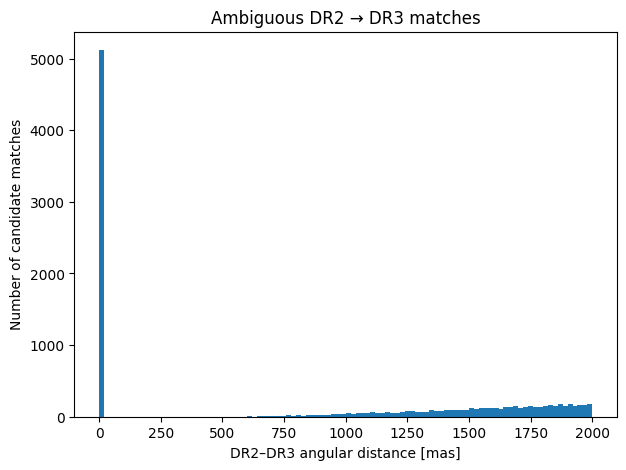

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.hist(
    ambiguous_matches["angular_distance"],
    bins=100
)

plt.xlabel("DR2–DR3 angular distance [mas]")
plt.ylabel("Number of candidate matches")
plt.title("Ambiguous DR2 → DR3 matches")
plt.show()

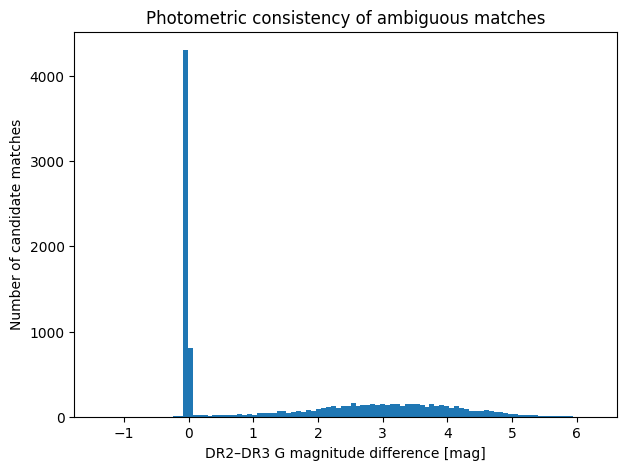

In [14]:
plt.figure(figsize=(7,5))
plt.hist(
    ambiguous_matches["magnitude_difference"],
    bins=100
)

plt.xlabel("DR2–DR3 G magnitude difference [mag]")
plt.ylabel("Number of candidate matches")
plt.title("Photometric consistency of ambiguous matches")
plt.show()

In [15]:
unique_matches["has_xp_continuous"] = (
    unique_matches["has_xp_continuous"].astype(bool)
)

n_unique = len(unique_matches)
n_xp = unique_matches["has_xp_continuous"].sum()

print("Unambiguous DR3 matches:", n_unique)
print("With XP continuous spectra:", n_xp)
print("Without XP continuous spectra:", n_unique - n_xp)
print(f"XP fraction: {100*n_xp/n_unique:.2f}%")

Unambiguous DR3 matches: 50074
With XP continuous spectra: 32468
Without XP continuous spectra: 17606
XP fraction: 64.84%


In [16]:
from astropy.table import Table

# Only unambiguous sources that have XP
xp_matches = unique_matches[
    unique_matches["has_xp_continuous"] == True
].copy()

xp_ids = (
    xp_matches["dr3_source_id"]
    .astype(np.int64)
    .drop_duplicates()
    .to_numpy()
)

print("XP sources:", len(xp_ids))

xp_upload = Table({
    "source_id": xp_ids
})

xp_upload[:5]

XP sources: 32468


source_id
int64
3396116127976921472
3723023749780397824
2423734436945921280
19182943147267968
2454864497346617344


In [17]:
from astroquery.gaia import Gaia
from astropy.table import Table, vstack
from pathlib import Path

import numpy as np
import time
import gc


# ============================================================
# SETTINGS
# ============================================================

OUTDIR = Path("Vasiliev_Sgr_XP_batches")
OUTDIR.mkdir(exist_ok=True)

# Start reasonably conservatively because Gaia has been unstable.
# If things run smoothly, you can later try 500.
BATCH_SIZE = 250

# If a large request repeatedly fails, automatically split it
# until requests this small are reached.
MIN_BATCH_SIZE = 10

MAX_RETRIES = 3

# Pause between successful requests
PAUSE_SECONDS = 2


# Make sure Gaia IDs have the correct integer type
xp_ids = np.asarray(xp_ids, dtype=np.int64)

print(f"Total requested XP sources: {len(xp_ids):,}")
print(f"Output directory: {OUTDIR.resolve()}")

Total requested XP sources: 32,468
Output directory: /home/gio/AstroPhysics/GalacticArchaeology/N-rich_XP_code/Vasiliev_Sgr_XP_batches


In [18]:
def convert_gaia_table(obj):
    """
    Convert a Gaia DataLink returned object into an Astropy Table.
    Works with both Table and VOTable TableElement objects.
    """

    if isinstance(obj, Table):
        return obj

    # VOTable TableElement
    if hasattr(obj, "to_table"):
        return obj.to_table(use_names_over_ids=True)

    # Fallback
    if hasattr(obj, "array"):
        return Table(obj.array)

    return Table(obj)

In [19]:
def retrieve_xp(ids):
    """
    Retrieve Gaia DR3 XP continuous coefficients for a set of source IDs.
    """

    ids = np.asarray(ids, dtype=np.int64)

    result = Gaia.load_data(
        ids=ids.tolist(),
        data_release="Gaia DR3",
        retrieval_type="XP_CONTINUOUS",
        data_structure="RAW",
        format="votable",
        verbose=False
    )

    tables = []

    for key, objects in result.items():

        for obj in objects:

            table = convert_gaia_table(obj)

            # Ignore metadata/empty tables
            if len(table) == 0:
                continue

            # We only want the actual XP table
            if "source_id" not in table.colnames:
                continue

            tables.append(table)

    if len(tables) == 0:
        raise RuntimeError(
            "Gaia returned no non-empty XP table containing source_id."
        )

    if len(tables) == 1:
        return tables[0]

    return vstack(
        tables,
        metadata_conflicts="silent"
    )

In [20]:
def get_already_downloaded():

    downloaded = set()

    files = sorted(OUTDIR.glob("xp_*.fits"))

    print(f"Existing batch files: {len(files)}")

    for file in files:

        try:
            table = Table.read(file)

            if "source_id" in table.colnames:

                ids = np.asarray(
                    table["source_id"],
                    dtype=np.int64
                )

                downloaded.update(
                    int(x) for x in ids
                )

        except Exception as e:

            print(f"WARNING: could not read {file}")
            print(e)

    return downloaded


already_downloaded = get_already_downloaded()

print(
    f"Already downloaded stars: "
    f"{len(already_downloaded):,}"
)

Existing batch files: 1
Already downloaded stars: 250


In [21]:
failed_ids = []


def save_xp_table(table):
    """
    Save one successfully downloaded XP table.
    """

    ids = np.asarray(
        table["source_id"],
        dtype=np.int64
    )

    first_id = int(ids[0])
    last_id = int(ids[-1])

    filename = (
        OUTDIR /
        f"xp_{first_id}_{last_id}_{len(table)}.fits"
    )

    table.write(
        filename,
        format="fits",
        overwrite=True
    )

    return filename


def download_group(ids, depth=0):
    """
    Download one group of IDs.

    If Gaia repeatedly fails, split the group in half
    and recursively try smaller groups.
    """

    global failed_ids

    ids = np.asarray(ids, dtype=np.int64)

    if len(ids) == 0:
        return

    indent = "    " * depth

    print(
        f"{indent}Requesting {len(ids):,} stars..."
    )

    # ========================================================
    # RETRIES
    # ========================================================

    for attempt in range(1, MAX_RETRIES + 1):

        try:

            table = retrieve_xp(ids)

            returned_ids = set(
                int(x)
                for x in np.asarray(
                    table["source_id"],
                    dtype=np.int64
                )
            )

            requested_ids = set(
                int(x) for x in ids
            )

            # -----------------------------------------------
            # Save what Gaia actually gave us
            # -----------------------------------------------

            if len(table) > 0:

                outfile = save_xp_table(table)

                print(
                    f"{indent}SUCCESS: "
                    f"{len(table):,}/{len(ids):,} "
                    f"saved -> {outfile.name}"
                )

            # -----------------------------------------------
            # Check whether Gaia omitted anything
            # -----------------------------------------------

            missing = requested_ids - returned_ids

            if len(missing) > 0:

                print(
                    f"{indent}WARNING: "
                    f"{len(missing)} IDs were not returned."
                )

                missing = np.asarray(
                    list(missing),
                    dtype=np.int64
                )

                download_group(
                    missing,
                    depth=depth + 1
                )

            gc.collect()
            time.sleep(PAUSE_SECONDS)

            return

        except Exception as e:

            print(
                f"{indent}Attempt "
                f"{attempt}/{MAX_RETRIES} failed:"
            )

            print(
                f"{indent}{type(e).__name__}: {e}"
            )

            if attempt < MAX_RETRIES:

                # Increasing wait:
                # 10 sec, 20 sec, ...
                wait = 10 * attempt

                print(
                    f"{indent}Waiting {wait} seconds..."
                )

                time.sleep(wait)

    # ========================================================
    # ALL RETRIES FAILED
    # ========================================================

    if len(ids) > MIN_BATCH_SIZE:

        midpoint = len(ids) // 2

        left = ids[:midpoint]
        right = ids[midpoint:]

        print(
            f"{indent}Splitting "
            f"{len(ids)} -> "
            f"{len(left)} + {len(right)}"
        )

        download_group(
            left,
            depth=depth + 1
        )

        download_group(
            right,
            depth=depth + 1
        )

    else:

        print(
            f"{indent}FAILED permanently "
            f"for {len(ids)} IDs."
        )

        failed_ids.extend(
            int(x) for x in ids
        )

In [22]:
already_downloaded = get_already_downloaded()

remaining_ids = np.asarray(
    [
        sid
        for sid in xp_ids
        if int(sid) not in already_downloaded
    ],
    dtype=np.int64
)

print()
print(f"Total target stars : {len(xp_ids):,}")
print(f"Already downloaded : {len(already_downloaded):,}")
print(f"Remaining          : {len(remaining_ids):,}")
print()

Existing batch files: 1

Total target stars : 32,468
Already downloaded : 250
Remaining          : 32,218



In [24]:
# ============================================================
# RESUMABLE GAIA XP DOWNLOAD WITH PROGRESS BAR
# ============================================================

import time
import numpy as np
from tqdm.auto import tqdm


# ------------------------------------------------------------
# Download settings
# ------------------------------------------------------------

# Number of stars sent to Gaia in each normal request
BATCH_SIZE = 25

# If a request repeatedly fails, split it until groups
# this small are reached
MIN_BATCH_SIZE = 5

# Number of attempts before splitting a failed group
MAX_RETRIES = 3

# Pause after successful requests
PAUSE_SECONDS = 2


# ------------------------------------------------------------
# Make sure IDs are proper integers
# ------------------------------------------------------------

xp_ids = np.asarray(xp_ids, dtype=np.int64)


# ------------------------------------------------------------
# Determine what has already been downloaded
# ------------------------------------------------------------

downloaded_ids = get_already_downloaded()

remaining_ids = np.array(
    [sid for sid in xp_ids if int(sid) not in downloaded_ids],
    dtype=np.int64
)

print()
print("=" * 70)
print(f"Total XP targets:       {len(xp_ids):,}")
print(f"Already downloaded:     {len(downloaded_ids):,}")
print(f"Remaining to download:  {len(remaining_ids):,}")
print(f"Request size:           {BATCH_SIZE}")
print("=" * 70)
print()


# Keep track of sources that fail even at the minimum batch size
failed_ids = []


# ============================================================
# DOWNLOAD FUNCTION
# ============================================================

def download_group(ids, pbar, depth=0):

    global failed_ids

    ids = np.asarray(ids, dtype=np.int64)

    if len(ids) == 0:
        return

    indent = "    " * depth

    # --------------------------------------------------------
    # Try this group
    # --------------------------------------------------------

    for attempt in range(1, MAX_RETRIES + 1):

        try:

            pbar.set_postfix_str(
                f"requesting {len(ids)} stars"
            )

            table = retrieve_xp(ids)

            if table is None or len(table) == 0:
                raise RuntimeError("Gaia returned an empty table.")

            # ------------------------------------------------
            # Determine which source IDs actually came back
            # ------------------------------------------------

            if "source_id" in table.colnames:

                returned_ids = np.asarray(
                    table["source_id"],
                    dtype=np.int64
                )

                returned_unique = np.unique(returned_ids)

            else:
                # Normally source_id should exist.
                # Fall back to treating the whole request
                # as successful.
                returned_unique = ids


            # ------------------------------------------------
            # Save this result immediately
            # ------------------------------------------------

            filename = (
                f"xp_{int(np.min(returned_unique))}_"
                f"{int(np.max(returned_unique))}_"
                f"{len(returned_unique)}.fits"
            )

            outfile = OUTDIR / filename

            table.write(
                outfile,
                overwrite=True
            )


            # ------------------------------------------------
            # Update progress bar
            # ------------------------------------------------

            n_saved = len(returned_unique)

            pbar.update(n_saved)

            pbar.set_postfix_str(
                f"saved {n_saved} stars"
            )


            # ------------------------------------------------
            # Check whether Gaia failed to return some IDs
            # ------------------------------------------------

            missing_ids = np.array(
                [
                    sid for sid in ids
                    if int(sid) not in set(returned_unique)
                ],
                dtype=np.int64
            )

            if len(missing_ids) > 0:

                tqdm.write(
                    f"{indent}Gaia returned "
                    f"{n_saved}/{len(ids)} stars. "
                    f"Retrying {len(missing_ids)} missing."
                )

                download_group(
                    missing_ids,
                    pbar,
                    depth=depth + 1
                )

            time.sleep(PAUSE_SECONDS)

            return


        except Exception as e:

            tqdm.write(
                f"{indent}Attempt {attempt}/{MAX_RETRIES} "
                f"failed for {len(ids)} stars:"
            )

            tqdm.write(
                f"{indent}{type(e).__name__}: {e}"
            )

            if attempt < MAX_RETRIES:
                time.sleep(5 * attempt)


    # ========================================================
    # ALL RETRIES FAILED
    # ========================================================

    # If the group is still large enough, split it
    if len(ids) > MIN_BATCH_SIZE:

        mid = len(ids) // 2

        left = ids[:mid]
        right = ids[mid:]

        tqdm.write(
            f"{indent}Splitting failed group of {len(ids)} "
            f"into {len(left)} + {len(right)}"
        )

        download_group(
            left,
            pbar,
            depth=depth + 1
        )

        download_group(
            right,
            pbar,
            depth=depth + 1
        )

    else:

        # Small group still failed after all retries
        tqdm.write(
            f"{indent}Giving up temporarily on "
            f"{len(ids)} source(s)."
        )

        failed_ids.extend(
            [int(x) for x in ids]
        )

        pbar.set_postfix_str(
            f"{len(failed_ids)} failed"
        )


# ============================================================
# RUN DOWNLOAD
# ============================================================

if len(remaining_ids) == 0:

    print("Nothing left to download!")

else:

    print(
        f"Starting approximately "
        f"{int(np.ceil(len(remaining_ids) / BATCH_SIZE)):,} "
        f"requests..."
    )

    print()

    with tqdm(
        total=len(remaining_ids),
        desc="Gaia XP download",
        unit="star",
        dynamic_ncols=True
    ) as pbar:

        for start in range(
            0,
            len(remaining_ids),
            BATCH_SIZE
        ):

            stop = min(
                start + BATCH_SIZE,
                len(remaining_ids)
            )

            batch_ids = remaining_ids[start:stop]

            download_group(
                batch_ids,
                pbar
            )


# ============================================================
# SUMMARY
# ============================================================

print()
print("=" * 70)
print("DOWNLOAD RUN COMPLETE")
print("=" * 70)

new_downloaded_ids = get_already_downloaded()

print(
    f"Downloaded total: "
    f"{len(new_downloaded_ids):,} / {len(xp_ids):,}"
)

print(
    f"Still missing:     "
    f"{len(xp_ids) - len(new_downloaded_ids):,}"
)

print(
    f"Failed this run:   "
    f"{len(set(failed_ids)):,}"
)

if len(failed_ids) > 0:

    print()
    print("Failed Gaia IDs:")

    for sid in sorted(set(failed_ids)):
        print(sid)

/home/gio/miniconda3/envs/mlastro/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Existing batch files: 1

Total XP targets:       32,468
Already downloaded:     250
Remaining to download:  32,218
Request size:           25

Starting approximately 1,289 requests...



Gaia XP download:   0%|          | 75/32218 [10:47<77:05:01,  8.63s/star, requesting 25 stars]


KeyboardInterrupt: 

In [25]:
import pandas as pd
import numpy as np

ids = np.asarray(xp_ids, dtype=np.int64)

xp_upload = pd.DataFrame({
    "source_id": ids,
    "chunk": np.arange(len(ids)) // 5000
})

xp_upload.to_csv(
    "sgr_xp_source_ids.csv",
    index=False
)

print(xp_upload)
print()
print(xp_upload.groupby("chunk").size())

                 source_id  chunk
0      3396116127976921472      0
1      3723023749780397824      0
2      2423734436945921280      0
3        19182943147267968      0
4      2454864497346617344      0
...                    ...    ...
32463  6601903636384054272      6
32464  6610616888076949248      6
32465  6794700938732681216      6
32466  6599738148233345664      6
32467  6601861575769069312      6

[32468 rows x 2 columns]

chunk
0    5000
1    5000
2    5000
3    5000
4    5000
5    5000
6    2468
dtype: int64
